### AdaBoost SAMME

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from IPython.display import display

print("NumPy version:", np.__version__)


NumPy version: 2.2.3


In [3]:
# Load data
data = np.load("processed_data.npz")
print("Keys:", list(data.files))

X_train = data["x_train"]
y_train = data["y_train"].astype(int)

X_val   = data["x_val"]
y_val   = data["y_val"].astype(int)

X_test  = data["x_test"]
y_test  = data["y_test"].astype(int)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Unique labels:", np.unique(y_train))


Keys: ['x_train', 'y_train', 'y_train_onehot', 'x_val', 'y_val', 'y_val_onehot', 'x_test', 'y_test', 'y_test_onehot']
Shapes: (50000, 28, 28) (10000, 28, 28) (10000, 28, 28)
Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [ ]:
def preprocess_28(X):
    X = X.reshape(X.shape[0], -1).astype(np.float32)  # (N, 784)
    X /= 255.0
    return X

def standardize_train_eval(X_train, X_val, X_test, eps=1e-8):
    mu = X_train.mean(axis=0, keepdims=True)
    std = X_train.std(axis=0, keepdims=True) + eps
    return (X_train - mu) / std, (X_val - mu) / std, (X_test - mu) / std, mu, std

def add_bias(X):
    return np.hstack([X, np.ones((X.shape[0], 1), dtype=X.dtype)])

X_train_f = preprocess_28(X_train)
X_val_f   = preprocess_28(X_val)
X_test_f  = preprocess_28(X_test)

X_train_f, X_val_f, X_test_f, mu, std = standardize_train_eval(X_train_f, X_val_f, X_test_f)

# Add bias term
X_train_f = add_bias(X_train_f)
X_val_f   = add_bias(X_val_f)
X_test_f  = add_bias(X_test_f)

print("Final shapes:", X_train_f.shape, X_val_f.shape, X_test_f.shape)
print("Feature stats (train): mean=%.4f std=%.4f min=%.4f max=%.4f" % (
    float(X_train_f.mean()), float(X_train_f.std()), float(X_train_f.min()), float(X_train_f.max())
))


Final shapes: (50000, 785) (10000, 785) (10000, 785)
Feature stats (train): mean=0.0013 std=0.9501 min=-1.2734 max=223.3174


## Weak Learner: Linear Softmax Classifier
Minibatch sampling theo phân phối w boosting đúng bản chất

huẩn hoá gradient theo tổng trọng số trong batch

Thêm L2 regularization nhẹ để ổn định


In [ ]:
class LinearSoftmaxClassifier:
    def __init__(self, n_features, n_classes, seed=42):
        rng = np.random.default_rng(seed)
        self.W = rng.normal(0.0, 0.01, size=(n_features, n_classes)).astype(np.float32)

    @staticmethod
    def softmax(logits):
        logits = logits - np.max(logits, axis=1, keepdims=True)
        exp_logits = np.exp(logits)
        return exp_logits / (np.sum(exp_logits, axis=1, keepdims=True) + 1e-12)

    def predict_proba(self, X):
        logits = X @ self.W
        return self.softmax(logits)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def fit_weighted(self, X, y, sample_weight, steps=1500, lr=0.03, batch_size=1024, reg=1e-4):
        n = X.shape[0]
        C = int(np.max(y)) + 1

        w = sample_weight.astype(np.float64)
        w = w / (w.sum() + 1e-12) 

        for step in range(steps):
            m = min(batch_size, n)
            idx = np.random.choice(n, size=m, replace=True, p=w)
            Xb = X[idx]
            yb = y[idx]
            wb = sample_weight[idx].astype(np.float64)

            logits = Xb @ self.W
            probs = self.softmax(logits)

            y_onehot = np.eye(C, dtype=np.float32)[yb]
            Z = wb.sum() + 1e-12

            grad = Xb.T @ ((probs - y_onehot) * (wb[:, None].astype(np.float32))) / float(Z)
            grad += reg * self.W 

            self.W -= lr * grad


## AdaBoost SAMME Thủ Công

Với K lớp, alpha dương khi \(\varepsilon < 1 - 1/K\).

Không nên cộng learner có alpha âm (vì làm hại ensemble). Ở đây giữ early_stop=True để dừng khi alpha<=0.


In [ ]:
class AdaBoostSAMME:
    def __init__(self, n_estimators=100, weak_learner_steps=1500, lr=0.03, early_stop=True,
                 batch_size=1024, reg=1e-4):
        self.n_estimators = n_estimators
        self.weak_learner_steps = weak_learner_steps
        self.lr = lr
        self.early_stop = early_stop
        self.batch_size = batch_size
        self.reg = reg

        self.weak_learners = []
        self.alphas = []
        self.errors = []
        self.weight_history = []
        self.n_classes = None

    def fit(self, X, y, verbose=True):
        n = X.shape[0]
        self.n_classes = len(np.unique(y))

        w = np.ones(n, dtype=np.float64) / n
        self.weight_history = [w.copy()]

        for t in range(self.n_estimators):
            clf = LinearSoftmaxClassifier(X.shape[1], self.n_classes, seed=42 + t)
            clf.fit_weighted(
                X, y, w,
                steps=self.weak_learner_steps,
                lr=self.lr,
                batch_size=self.batch_size,
                reg=self.reg
            )

            pred = clf.predict(X)
            incorrect = (pred != y).astype(np.float64)

            weighted_error = float(np.sum(w * incorrect))
            weighted_error = float(np.clip(weighted_error, 1e-12, 1 - 1e-12))

            alpha = float(np.log((1 - weighted_error) / weighted_error) + np.log(self.n_classes - 1))

            if self.early_stop and alpha <= 0:
                if verbose:
                    print(f"Early stop tại round {t+1}: err={weighted_error:.4f} | alpha={alpha:.4f}")
                break

            # update weights
            w = w * np.exp(alpha * incorrect)
            w = w / (w.sum() + 1e-12)

            self.weak_learners.append(clf)
            self.alphas.append(alpha)
            self.errors.append(weighted_error)
            self.weight_history.append(w.copy())

            if verbose:
                print(f"Round {t+1:03d} | err={weighted_error:.4f} | alpha={alpha:.4f}")

        return self

    def predict(self, X):
        n = X.shape[0]
        scores = np.zeros((n, self.n_classes), dtype=np.float64)

        for clf, alpha in zip(self.weak_learners, self.alphas):
            pred = clf.predict(X)
            scores[np.arange(n), pred] += alpha 

        return np.argmax(scores, axis=1)


## Metrics 

In [7]:
def accuracy(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

def confusion_matrix(y_true, y_pred, n_classes=10):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm

def precision_recall_f1_macro(cm):
    n_classes = cm.shape[0]
    prec, rec, f1 = [], [], []
    for i in range(n_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0
        prec.append(p); rec.append(r); f1.append(f)
    return float(np.mean(prec)), float(np.mean(rec)), float(np.mean(f1))


## Sanity check: 1 weak learner trước khi Boosting

Nếu accuracy của weak learner ~0.75–0.85 trên validation, boosting sẽ hoạt động tốt.


In [8]:
# Sanity check: train 1 weak learner (không boosting)
clf = LinearSoftmaxClassifier(X_train_f.shape[1], 10, seed=0)
w0 = np.ones(len(y_train), dtype=np.float64) / len(y_train)

clf.fit_weighted(X_train_f, y_train, w0, steps=1500, lr=0.03, batch_size=1024, reg=1e-4)
val_pred_1 = clf.predict(X_val_f)
print("Weak learner val acc:", accuracy(y_val, val_pred_1))


Weak learner val acc: 0.9117


## Tìm Best T dựa trên Validation


In [ ]:
val_accs = []
best_val_acc = -1
best_T = 10

T_candidates = [10, 20, 30, 40, 50, 70]

for T in T_candidates:
    model = AdaBoostSAMME(
        n_estimators=T,
        weak_learner_steps=1200,  
        lr=0.03,
        early_stop=True,
        batch_size=1024,
        reg=1e-4
    )
    model.fit(X_train_f, y_train, verbose=False)

    val_pred = model.predict(X_val_f)
    val_acc = accuracy(y_val, val_pred)
    val_accs.append(val_acc)

    print(f"T={T:2d} | rounds_used={len(model.weak_learners)} | val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_T = T

print(f"\nBest T theo validation: {best_T} (val_acc = {best_val_acc:.4f})")


T=10 | rounds_used=10 | val_acc=0.8400
T=20 | rounds_used=20 | val_acc=0.8564
T=30 | rounds_used=30 | val_acc=0.8632
T=40 | rounds_used=40 | val_acc=0.8662
T=50 | rounds_used=50 | val_acc=0.8679
T=70 | rounds_used=70 | val_acc=0.8717

Best T theo validation: 70 (val_acc = 0.8717)


In [10]:
# Train final model với best_T
final_model = AdaBoostSAMME(
    n_estimators=best_T,
    weak_learner_steps=1500,
    lr=0.03,
    early_stop=True,
    batch_size=1024,
    reg=1e-4
)
final_model.fit(X_train_f, y_train, verbose=True)

# Evaluate trên test
test_pred = final_model.predict(X_test_f)
test_acc = accuracy(y_test, test_pred)
cm = confusion_matrix(y_test, test_pred)
p_macro, r_macro, f1_macro = precision_recall_f1_macro(cm)

print("\nTEST RESULTS")
print(f"Accuracy: {test_acc:.4f}")
print(f"Precision (macro): {p_macro:.4f}")
print(f"Recall (macro): {r_macro:.4f}")
print(f"F1 (macro): {f1_macro:.4f}")


Round 001 | err=0.0787 | alpha=4.6579
Round 002 | err=0.4349 | alpha=2.4591
Round 003 | err=0.4704 | alpha=2.3159
Round 004 | err=0.3883 | alpha=2.6516
Round 005 | err=0.4767 | alpha=2.2907
Round 006 | err=0.4014 | alpha=2.5969
Round 007 | err=0.4382 | alpha=2.4458
Round 008 | err=0.3812 | alpha=2.6819
Round 009 | err=0.3435 | alpha=2.8448
Round 010 | err=0.3899 | alpha=2.6452
Round 011 | err=0.3896 | alpha=2.6461
Round 012 | err=0.3852 | alpha=2.6648
Round 013 | err=0.4196 | alpha=2.5215
Round 014 | err=0.3577 | alpha=2.7827
Round 015 | err=0.4254 | alpha=2.4978
Round 016 | err=0.4097 | alpha=2.5623
Round 017 | err=0.3841 | alpha=2.6696
Round 018 | err=0.4161 | alpha=2.5359
Round 019 | err=0.3955 | alpha=2.6214
Round 020 | err=0.3960 | alpha=2.6192
Round 021 | err=0.4184 | alpha=2.5268
Round 022 | err=0.3894 | alpha=2.6469
Round 023 | err=0.4090 | alpha=2.5653
Round 024 | err=0.3844 | alpha=2.6681
Round 025 | err=0.4006 | alpha=2.6000
Round 026 | err=0.4019 | alpha=2.5947
Round 027 | 

## Visualization & Analysis


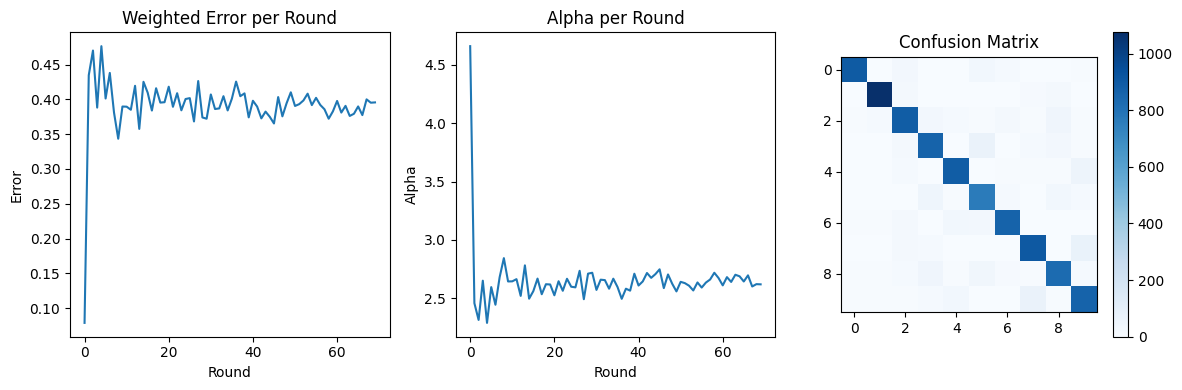

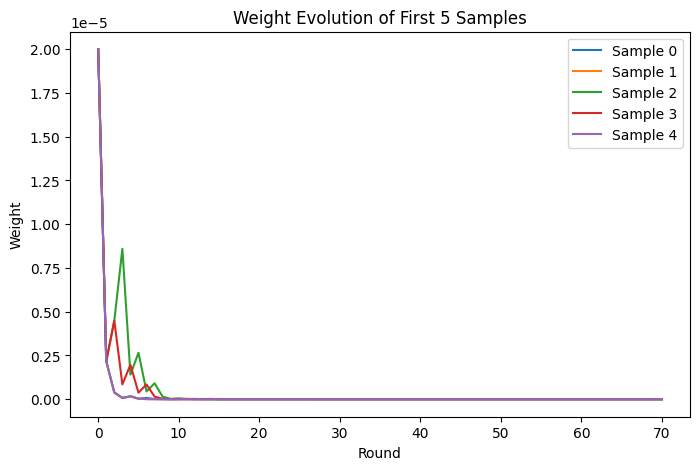

In [11]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(final_model.errors)
plt.title("Weighted Error per Round")
plt.xlabel("Round")
plt.ylabel("Error")

plt.subplot(1,3,2)
plt.plot(final_model.alphas)
plt.title("Alpha per Round")
plt.xlabel("Round")
plt.ylabel("Alpha")

plt.subplot(1,3,3)
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()

# Weight evolution (5 samples đầu tiên)
weights_arr = np.array(final_model.weight_history)
plt.figure(figsize=(8,5))
for i in range(min(5, weights_arr.shape[1])):
    plt.plot(weights_arr[:, i], label=f"Sample {i}")
plt.title("Weight Evolution of First 5 Samples")
plt.xlabel("Round")
plt.ylabel("Weight")
plt.legend()
plt.show()


## Lưu kết quả


In [12]:
# Lưu model
with open("adaboost_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

# Lưu row kết quả
result_row = pd.DataFrame([{
    "Model": "AdaBoost SAMME (Hand-crafted NumPy, 28x28)",
    "Best_T_by_val": int(best_T),
    "Used_Rounds": int(len(final_model.weak_learners)),
    "Accuracy": round(float(test_acc), 4),
    "Precision_macro": round(float(p_macro), 4),
    "Recall_macro": round(float(r_macro), 4),
    "F1_macro": round(float(f1_macro), 4)
}])

result_row.to_csv("AdaBoost_result_row.csv", index=False)
display(result_row)

# Stub cho MASTER_COMPARISON (bạn sẽ thêm từ TV1-4)
master = result_row.copy()
master.to_csv("MASTER_COMPARISON.csv", index=False)
print("Đã lưu: adaboost_model.pkl, AdaBoost_result_row.csv, MASTER_COMPARISON.csv")


,Model,Best_T_by_val,Used_Rounds,Accuracy,Precision_macro,Recall_macro,F1_macro
0,"AdaBoost SAMME (Hand-crafted NumPy, 28x28)",70,70,0.8843,0.8841,0.8833,0.8836


Đã lưu: adaboost_model.pkl, AdaBoost_result_row.csv, MASTER_COMPARISON.csv
